# Часть 1 — Сборка с Velvet

В этом задании будет производить сборку генома. В качестве исходных данных будем использовать genome_de_novo.zip. Осуществим сборку 4 k-mer с шагом ~10 с использованием программы [Velvet](https://github.com/dzerbino/velvet). В качетсве k-mer выбраны: k31, k43, k55, k65.

Скрипт для выполнения сборки содержится в файле [velvet_job.slurm](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/blob/main/hw4/scripts/velvet_job.slurm):

In [ ]:
#!/bin/bash
#SBATCH --job-name=hw4_velvet
#SBATCH --cpus-per-task=4
#SBATCH --mem=8gb
#SBATCH --time=02:00:00
#SBATCH --output=~/hw4_velvet_assembly/logs/velvet_%j.log
#SBATCH --error=~/hw4_velvet_assembly/logs/velvet_%j.err
#SBATCH --partition=AMD9554-common

# Пути
VELVET_DIR="$HOME/velvet"
DATA_DIR="$HOME/hw4_velvet_assembly/data"
OUTPUT_BASE="$HOME/hw4_velvet_assembly/results/velvet"

# K-mer значения (31, 43, 55, 65)
KMERS=(31 43 55 65)
INS_LENGTH=300

for k in "${KMERS[@]}"; do
    echo ""
    echo "=== k=$k ==="
    OUTPUT_DIR="${OUTPUT_BASE}/k${k}"
    mkdir -p $OUTPUT_DIR

    $VELVET_DIR/velveth $OUTPUT_DIR $k -fastq -shortPaired \
        $DATA_DIR/7_S4_L001_R1_001.fastq \
        $DATA_DIR/7_S4_L001_R2_001.fastq

    $VELVET_DIR/velvetg $OUTPUT_DIR -ins_length $INS_LENGTH

    echo "k=$k done:"
    grep "Final assembly" $OUTPUT_DIR/stats.txt
done

echo "Results: $OUTPUT_BASE"

В результате работы программы получены файлы сборки:

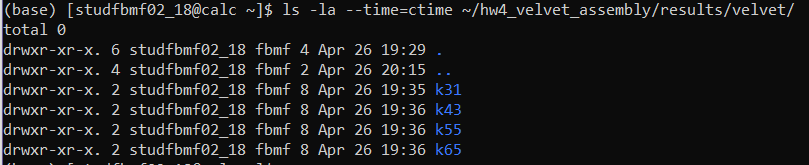

# Часть 2 — Сравнение сборок

Проведем сборку SPAdes (используем код с семинара). Для сборки в данном случае k-mer: 21, 33, 55, 77 (подобраны автоматически).




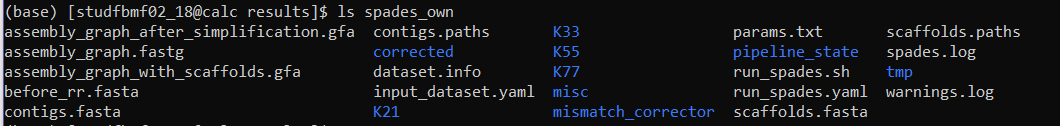

Сравним сборки, полученные Velvet и SPAdes сборки при помощи QUAST. При анализе QUAST отбросил k31, k43.

QUAST: [quast_all](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/tree/main/hw4/QUASTs/quast_all)

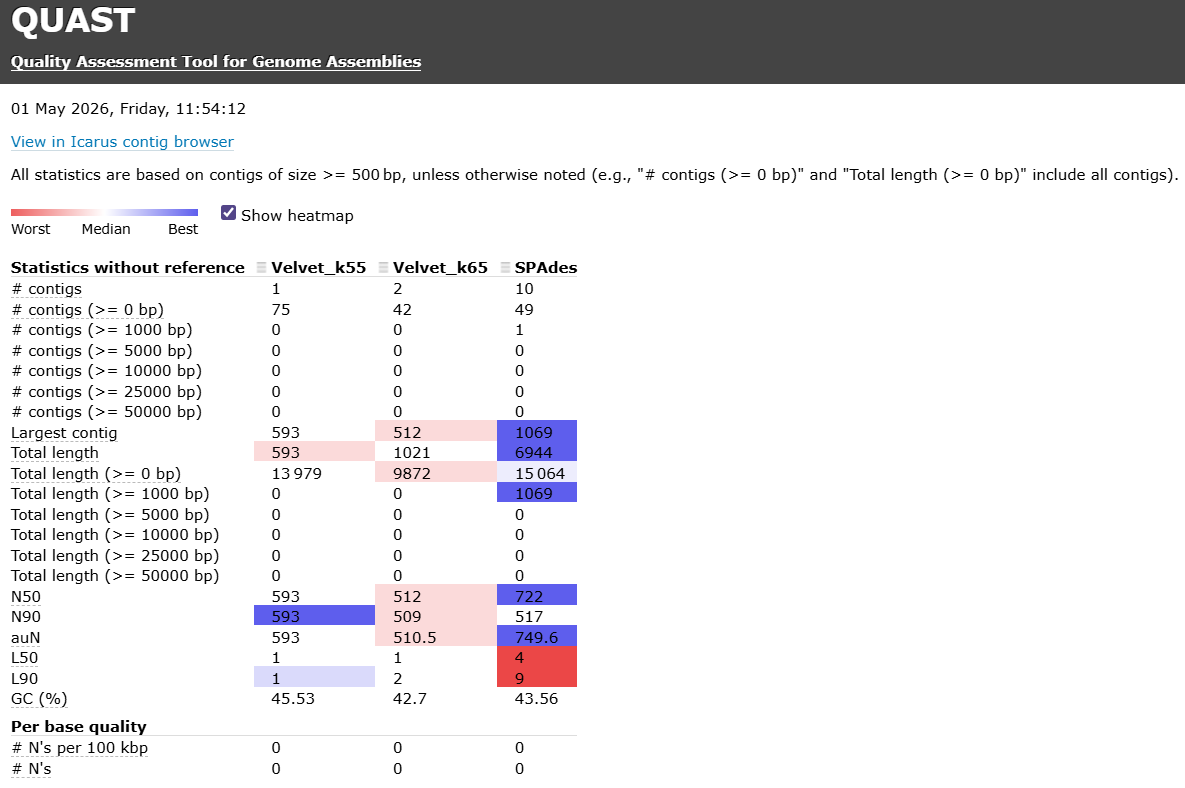

По большинству показателей выигрывает сборка SPAdes. Для нее характерна более высокая полнота сборки, при этом SPAdes использует более длинные фрагменты (Largest contig = 1069). N50 означает, что 50% всего собранного генома находится в контигах длиной не менее 722 пар оснований. При этом более 90% генома в контигах длиной не менее 517 bp. Интегральный параметр auN (средневзвешенное арифметическое всех Nx), составляющий 749.6, обобщает качество сборки по всем N-метрикам. Поскольку auN выше, чем N50 (749.6 > 722), это указывает на то, что сборка содержит несколько особенно длинных контигов.

С другой стороны SPAdes проигрывает сборкам Velvet, так как использует большее количество контигов (более фрагментированная сборкa у SPAdes), а также более высокие показатели L50 и L90 (cколько контигов нужно, чтобы покрыть 50% и 90% собранного генома). Но эти показатели компенсируются более длинной сборкой для SPAdes, для Velvet в несколько раз ниже. Среди сборок Velvet немного лучше показатели для k55, но при этом самый короткий собранный геном.

# Часть 3 — Улучшение сборки

Попробуем улучшить сборки. Для сборки SPAdes проверим три варианта по улучшению. Во всех вариантах в качестве подхода к улучшению сборки используем тримминг исходных данных.

In [ ]:
# вариант 1

#мягкий тримминг
./fastp -i /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/7_S4_L001_R1_001.fastq \
        -I /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/7_S4_L001_R2_001.fastq \
        -o /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R1_balanced.fastq \
        -O /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R2_balanced.fastq \
        --cut_front --cut_tail \ # обрезание последовательностей низкого качества секвенирования с начала и конца рида (напр. остатки праймеров)
        --cut_window_size 4 --cut_mean_quality 12 \ #размер скользящего окна (локальная оценка качества, вместо усредненной по риду); порог качества
        --length_required 25 \ # нижняя граница длины ридов
        --average_qual 12 # отсеивает риды с слишком большим количеством ошибок (качество ниже порогового)

/home/STUDY/FBMF/bioinformatics/soft/SPAdes-4.2.0-Linux/bin/spades.py \
    --careful \ #MismatchCorrector (Bсправляет ошибки в контигах)
    --cov-cutoff auto \ #автоматическоe определения порога покрытия (coverage cutoff) -> Снижение шума, устранение ошибок
    -k 21,33,55,77,99,127 \ #расширенный диапозон k-mer (позволяет использовать более длинные континги)
    -1 /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R1_balanced.fastq \
    -2 /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R2_balanced.fastq \
    -o /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/results/spades_careful

In [ ]:
# вариант 2
./fastp \
    -i /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/7_S4_L001_R1_001.fastq \
    -I /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/7_S4_L001_R2_001.fastq \
    -o /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R1_final.fastq \
    -O /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R2_final.fastq \
    --cut_front \
    --cut_tail \
    --cut_window_size 4 \
    --cut_mean_quality 15 \
    --length_required 25 \
    --detect_adapter_for_pe \ #aвто-определение и удаление адаптеров
    --thread 8 #используемое количество ядер CPU (ускорение работы)

/home/STUDY/FBMF/bioinformatics/soft/SPAdes-4.2.0-Linux/bin/spades.py \
     --careful \
     --cov-cutoff auto \
     -k 21,33,55,77,99,127 \
     -1 /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R1_final.fastq \
     -2 /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R2_final.fastq \
     -o /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/results/spades_final_vers


QUAST: [quast_spades_three](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/tree/main/hw4/QUASTs/quast_spades_three)

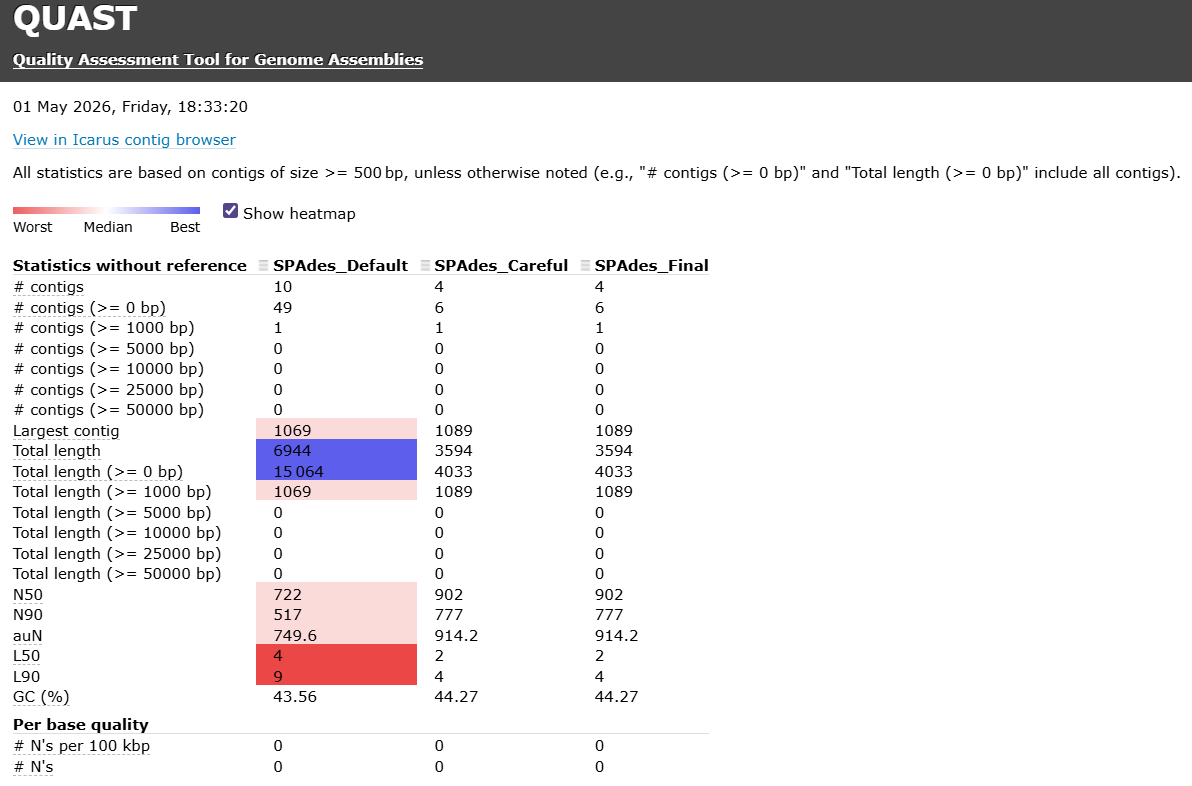

При сравнении вариантов 1 и 2 не было выявлено различий в результатах между ними. По сравнению с результатом исходной SPAdes сборки наблюдается значительное сокращение количества контингов и используемых малых последовательностей. Увеличилось использование в сборке длинных контигов (N50, N90, auN) Для покрытия 50% (как и 90%) генома количество необходимых контигов сократилось примерно в двое. Вместе с этим в двое сократилась и общая длина сборки.

In [ ]:
# вариант 3
./fastp \
    -i /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/7_S4_L001_R1_001.fastq \
    -I /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/7_S4_L001_R2_001.fastq \
    -o /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R1_final.fastq \
    -O /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R2_final.fastq \
    --cut_front \
    --cut_tail \
    --cut_window_size 4 \
    --cut_mean_quality 15 \
    --length_required 25 \
    --detect_adapter_for_pe \
    --thread 8


/home/STUDY/FBMF/bioinformatics/soft/SPAdes-4.2.0-Linux/bin/spades.py \
    --careful \
    -k 21,33,55,77,99,127 \
    -1 /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R1_final.fastq \
    -2 /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/data/R2_final.fastq \
    -o /home/STUDY/FBMF/studfbmf02_18/hw4_velvet_assembly/results/spades_final

    # Убрали --cov-cutoff auto, что позволило сохранить low-coverage контиги, которые ранее отбрасывались. Может привести к увеличению длины сборки

Обратим внимание на повтор названий в QUAST при двух проверках (замечено уже при обработке результатов). На фотографии ниже сравнивается 1 и 3 варианты сборок.

QUAST: [quast_3_final](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/tree/main/hw4/QUASTs/quast_3_final)

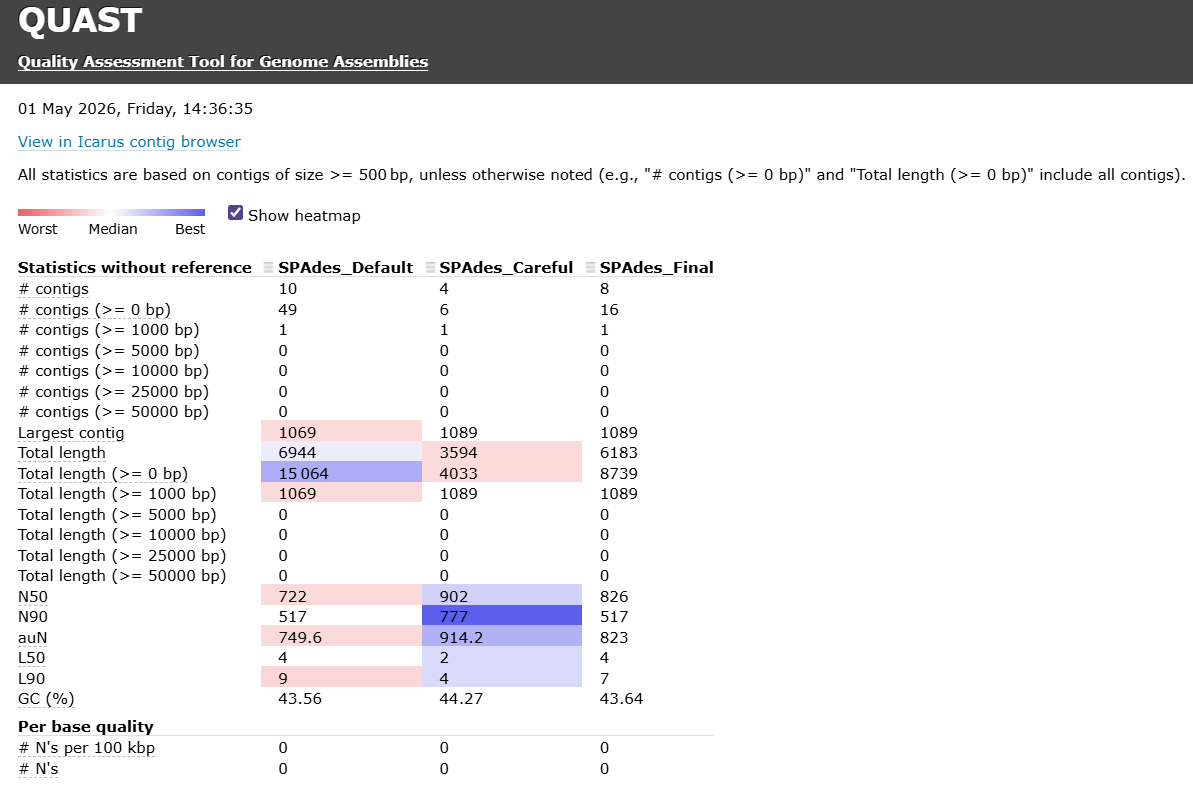

Как и ожидалось, при исключении параметра --cov-cutoff auto удалось увеличить длину сборки практически до исходного значения. При этом получилось добиться улучшений по другим параметрам. Также удалось добиться сокращения количества контигов, увеоичить преобладание длинных фрагментов в сборке (N50, auN), немного сократить L90. Эти улучшения получены без потерь качества по сравнению с исходной моделью. Вариант 3 можно считать оптимальным.

Теперь перейдем к улучшению Velvet-сборки. Исключили из сборки k31 и k43, так как QUAST отбрасывал их из анализа. Применили мягкий тримминг к данным и проводили сборку уже на них. Также произвели сборку с k75, но оставим ее вне анализа, так как цель улучшить Velvet-сборки по уже имеющимся k-mer.

In [ ]:
./fastp \
    -i ~/hw4_velvet_assembly/data/7_S4_L001_R1_001.fastq \
    -I ~/hw4_velvet_assembly/data/7_S4_L001_R2_001.fastq \
    -o ~/hw4_velvet_assembly/data/R1_gentle.fastq \
    -O ~/hw4_velvet_assembly/data/R2_gentle.fastq \
    --cut_front --cut_tail \
    --cut_window_size 4 --cut_mean_quality 10 \
    --length_required 15 \
    --detect_adapter_for_pe

Скрипт: [velvet_gentle.slurm](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/blob/main/hw4/scripts/velvet_gentle.slurm)

In [ ]:
#!/bin/bash
#SBATCH --job-name=velvet_gentle
#SBATCH --cpus-per-task=4
#SBATCH --mem=8gb
#SBATCH --time=02:00:00
#SBATCH --output=~/hw4_velvet_assembly/logs/velvet_gentle_%j.log
#SBATCH --error=~/hw4_velvet_assembly/logs/velvet_gentle_%j.err
#SBATCH --partition=AMD9554-common

VELVET_DIR="$HOME/velvet"
OUTPUT_BASE="$HOME/hw4_velvet_assembly/results/velvet_gentle"

KMERS=(55 65 75)
INS_LENGTH=300

for k in "${KMERS[@]}"; do
    echo "=== Velvet мягкий тримминг k=$k ==="
    OUTPUT_DIR="${OUTPUT_BASE}/k${k}"
    mkdir -p $OUTPUT_DIR

    $VELVET_DIR/velveth $OUTPUT_DIR $k -fastq -shortPaired \
        ~/hw4_velvet_assembly/data/R1_gentle.fastq \
        ~/hw4_velvet_assembly/data/R2_gentle.fastq

    $VELVET_DIR/velvetg $OUTPUT_DIR -ins_length $INS_LENGTH

    echo "Результат:"
    grep "Final assembly" $OUTPUT_DIR/stats.txt
    echo "Количество контигов: $(grep -c '^>' $OUTPUT_DIR/contigs.fa)"
done

echo ""
echo "=== Все сборки завершены ==="
echo "Результаты в: $OUTPUT_BASE"

QUAST: [quast_velvet_gentle](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/tree/main/hw4/QUASTs/quast_velvet_gentle)

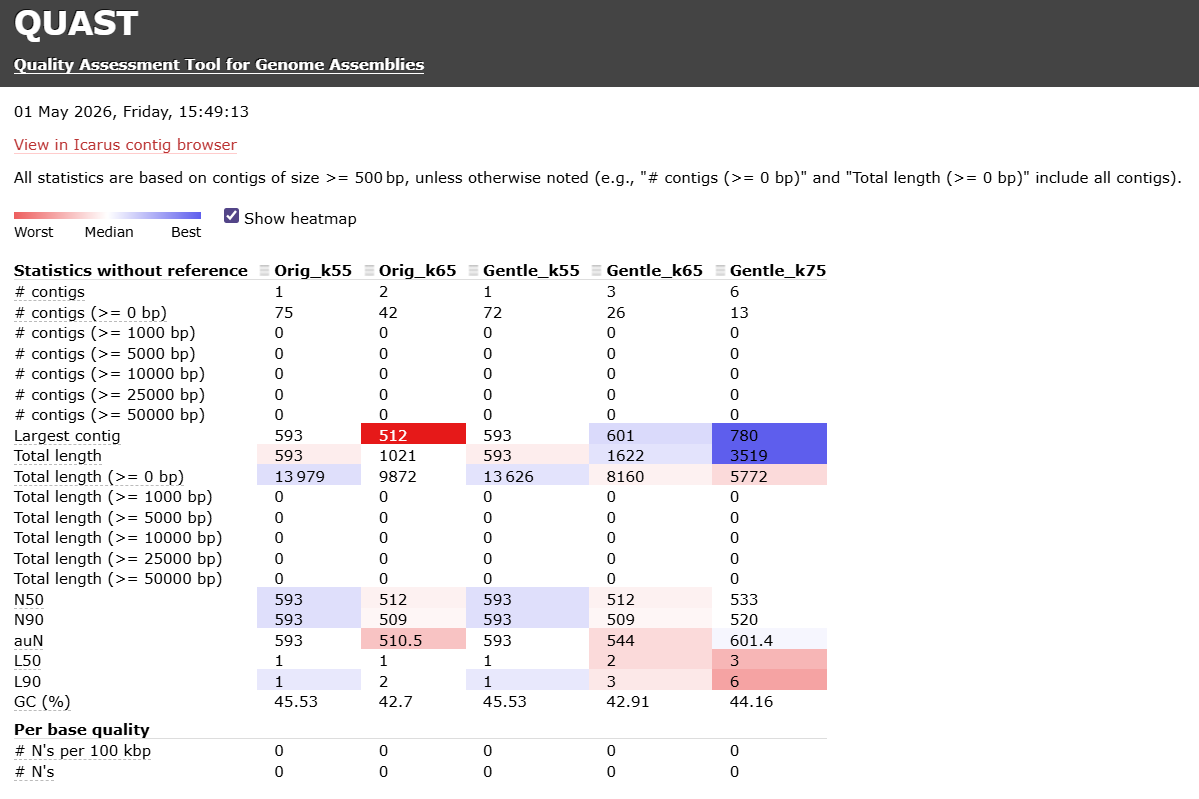

Провели сравнение сборок QUAST. Для k55 не выявлены изменения в качестве сборки, только незначительно снизились общая длина сборки и количество использования коротких контигов.


QUAST: [quast_velvet_final](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/tree/main/hw4/QUASTs/quast_velvet_final)

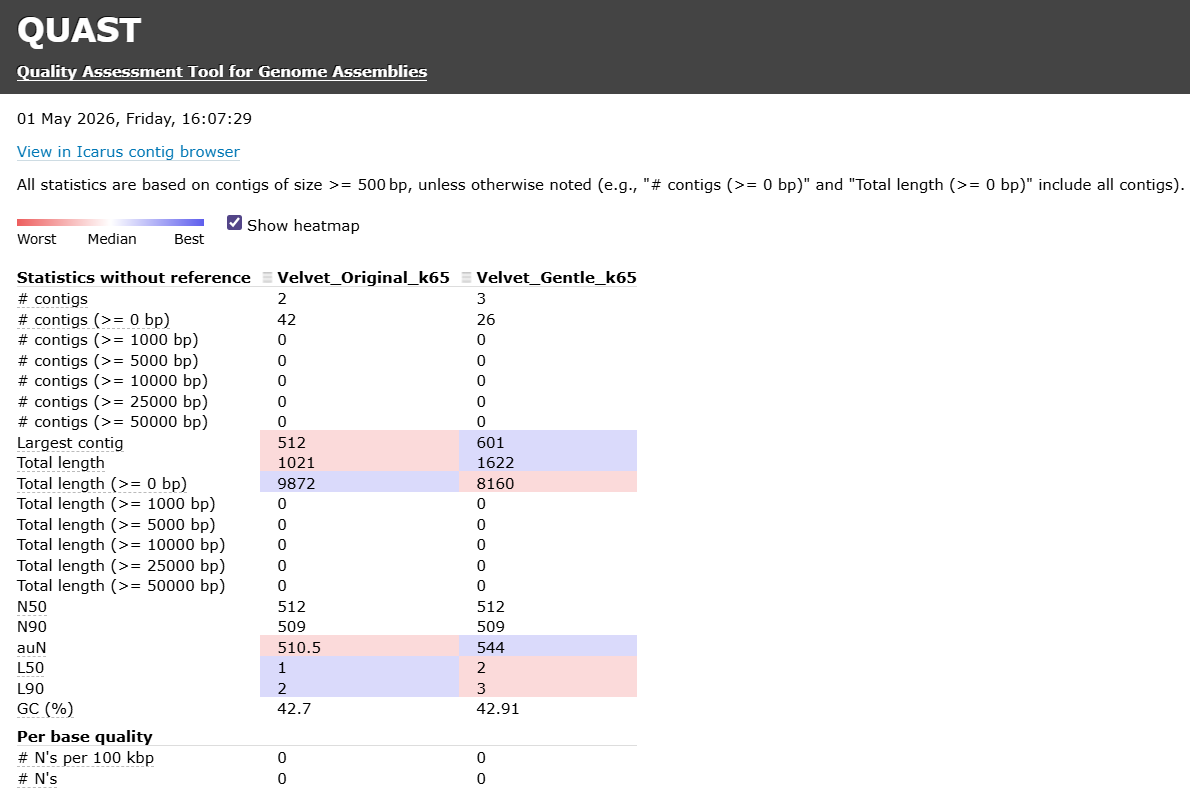

Для k65 наблюдается увеличение общей длины сборки в 1,5 раза. При неизменных параметрах N50, N90 наблюдается увеличение AuN (То есть участилось использование более длинных контигов). С увеличением длины сборки закономерно увеличились (но не сильно) параметры L50 и L90.

QUAST: [quast_all_final](https://github.com/ArinaChebykina/Bioinformatics26_ArinaCh/tree/main/hw4/QUASTs/quast_all_final)

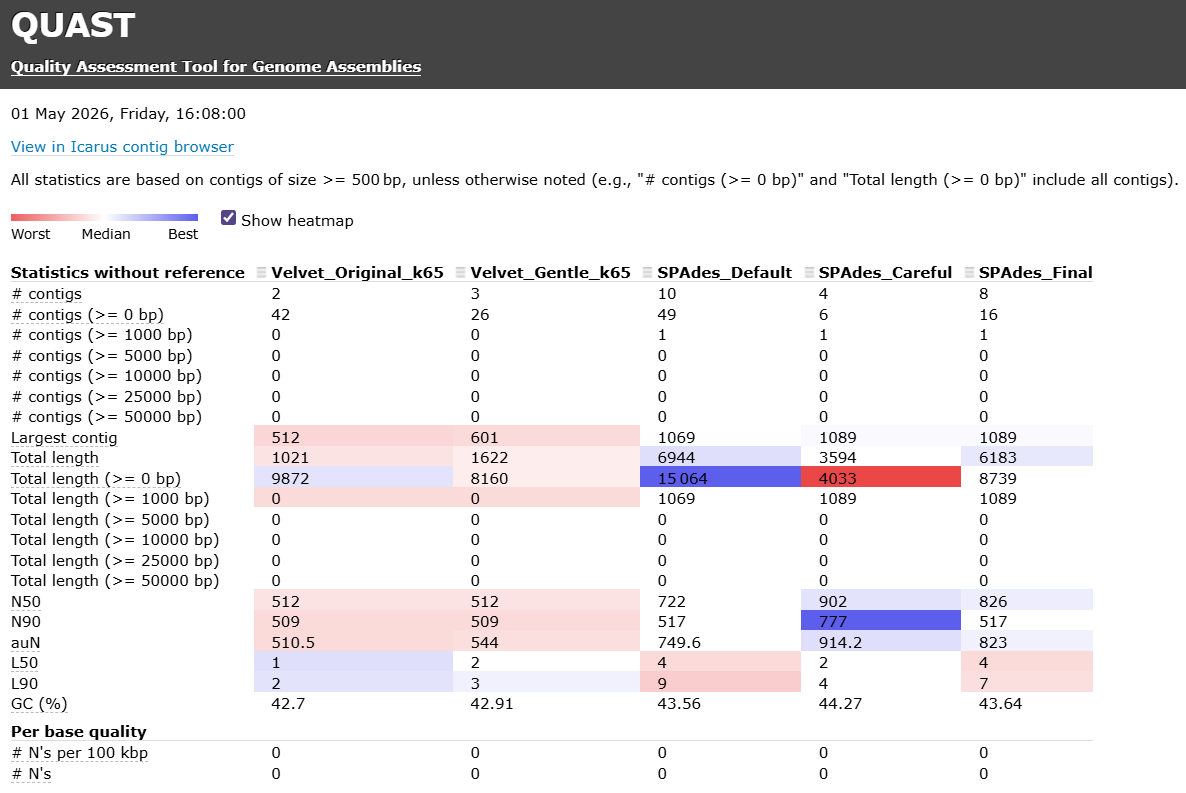

С применением улучшений к сборкам Velvet и SPAdes произошли изменения в характеристиках сборок только среди сборок одного типа. Качество сборки SPAdes так и сохраняет преимущество перед сборкой Velvet.